# 0. Import Packages and Modules

In [1]:
%%capture
import numpy as np
from PDE.pde_model import PDE
from PDE.pde_solver import solve_pde
from PDE.pde_controller import solve_kernel
from plot import plot_pde, plot_kernel, plot_lambda, plot_observer_error
from DeepONet.generate_data import generate_lambda_dataset, generate_kernel_dataset
from DeepONet.training import train_deeponet_model, load_deeponet_model, compute_k_hat

---

# 1. Open Loop PDE

PDE:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= 0.
\end{align}
$

In the paper, the open-loop PDE is solved for two different $\lambda(x)$, defined as

$
\begin{align}
\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right),\\
\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right).
\end{align}
$

## 1-1. Define PDEs

In [2]:
# Define PDE for λ(x) = 50cos(5ccos^-1(x))
def lambda_func1(x): return 50 * np.cos(5 * np.arccos(x))
pde1 = PDE(lambda_func=lambda_func1)

# Define PDE for λ(x) = 50cos(8ccos^-1(x))
def lambda_func2(x): return 50 * np.cos(8 * np.arccos(x))
pde2 = PDE(lambda_func=lambda_func2)

## 1-2. Solve Open Loop PDEs

In [3]:
# Solve open loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x))
u1_ol, _ = solve_pde(pde1)

# Solve open loop PDE u(x,t) for λ(x) = 50cos(8ccos^-1(x))
u2_ol, _ = solve_pde(pde2)

## 1-3. Plot Open Loop Results

### 1-3-1. Plot $\lambda(x)$

My Results:

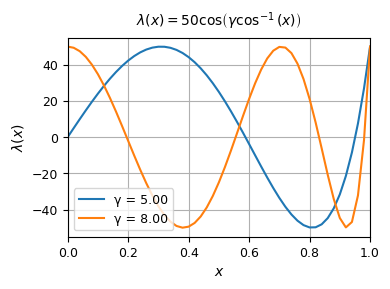

In [4]:
# Plot λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_lambda(x=pde1.x, lambda_func=np.vstack([lambda_func1(pde1.x), lambda_func2(pde2.x)]), gamma=np.array([5, 8]), title=r'$\lambda(x)=50\cos\!\left(\gamma\cos^{-1}(x)\right)$')

Paper Results:

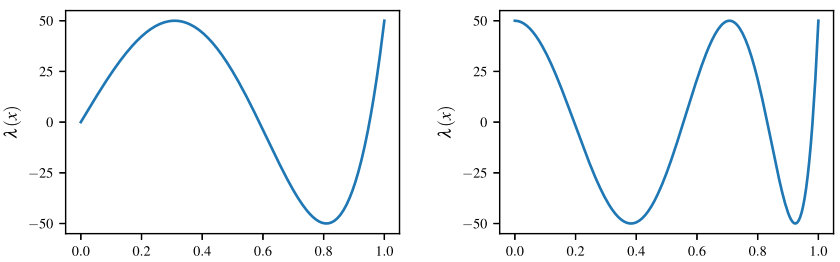

### 1-3-2. Plot Open Loop PDEs

My Results:

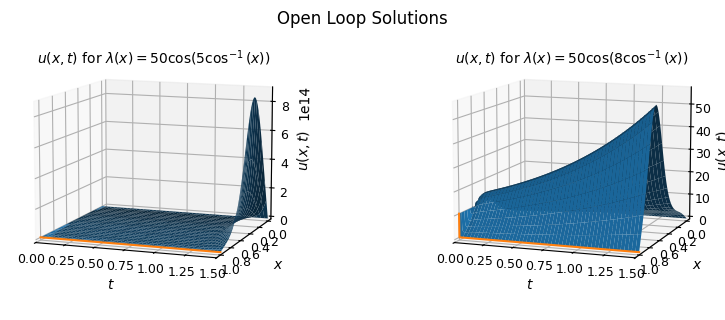

In [5]:
# Plot open loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_pde(pde1.x, pde1.t, [u1_ol, u2_ol], fig_title=r'Open Loop Solutions' , title=[r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$'], z_title=[r'$u(x,t)$', r'$u(x,t)$'], cols=2)

Paper Results:

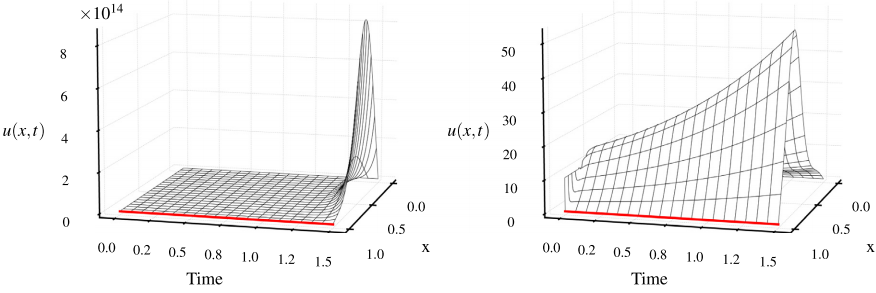

---

# 2. Closed-Loop PDE (Backstepping Control)

PDE:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= U(t).
\end{align}
$

where

$
\begin{align}
U(t) = \int_0^1 k(1, y)\, u(y, t) \, dy
\end{align}
$

## 2-1. Define PDEs

In [6]:
# Define PDE for λ(x) = 50cos(5ccos^-1(x))
def lambda_func1(x): return 50 * np.cos(5 * np.arccos(x))
pde1 = PDE(lambda_func=lambda_func1)

# Define PDE for λ(x) = 50cos(8ccos^-1(x))
def lambda_func2(x): return 50 * np.cos(8 * np.arccos(x))
pde2 = PDE(lambda_func=lambda_func2)

## 2-2. Compute Kernel

Kernel PDE:

$
\begin{align}
k_{xx}(x, y) - k_{yy}(x, y) &= \lambda(y) k(x, y), \quad \forall (x, y) \in \check{T}, \\
k(x, 0) &= 0, \\
k(x, x) &= -\frac{1}{2} \int_0^x \lambda(y) \, dy.
\end{align}
$

In [7]:
# Solve kernel PDE for λ(x) = 50cos(5ccos^-1(x))
k1 = solve_kernel(pde1)

# Solve kernel PDE for λ(x) = 50cos(8ccos^-1(x))
k2 = solve_kernel(pde2)

## 2-3. Solve Closed Loop PDE

In [8]:
# Solve closed loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x))
u1_cl, _ = solve_pde(pde1, k=k1)

# Solve closed loop PDE u(x,t) for λ(x) = 50cos(8ccos^-1(x))
u2_cl, _ = solve_pde(pde2, k=k2)

## 2-4. Plot Closed Loop Results

### 2-4-1. Plot Kernels

My Results:

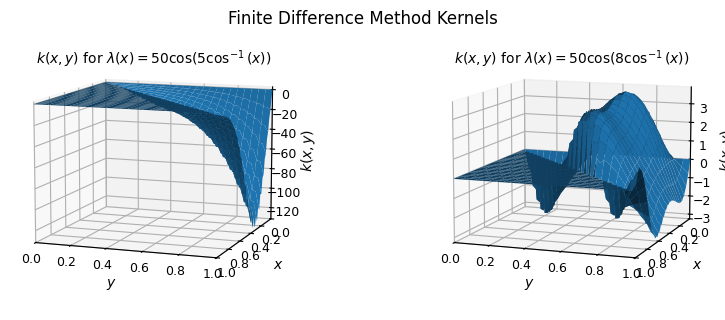

In [9]:
# Plot kernels for λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_kernel(pde1.x, kernel=[k1, k2], fig_title=r'Finite Difference Method Kernels', title=[r'$k(x,y)$ for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', r'$k(x,y)$ for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$'], z_title=[r'$k(x,y)$', r'$k(x,y)$'], cols=2)

Paper Results:

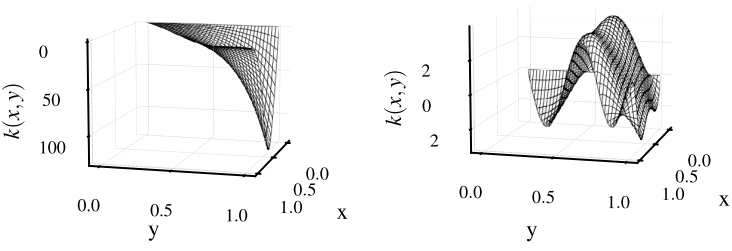

### 2-4-2. Plot Closed Loop PDEs

My Results:

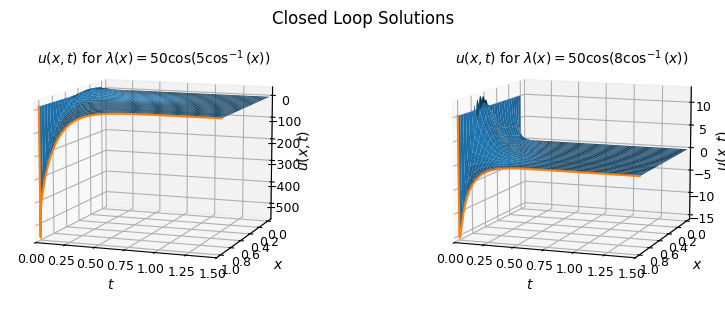

In [10]:
# Plot closed loop PDE u(x,t) for λ(x) = 50cos(5ccos^-1(x)) and λ(x) = 50cos(8ccos^-1(x))
plot_pde(pde1.x, pde1.t, [u1_cl, u2_cl], fig_title=r'Closed Loop Solutions', title=[r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', r'$u(x,t)$ for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$'], z_title=[r'$u(x,t)$', r'$u(x,t)$'], cols=2)

Paper Results:

The paper does not include results for the closed-loop solution when the kernel is computed using the finite difference method. It only includes closed-loop results when the kernel is computed using neural operators, which is the main contribution of the paper.

---

# 3. Observer Design (Backstepping Observer)

PDE:

$
\begin{align}
u_t(x,t) &= u_{xx}(x,t) + \lambda(x)\,u(x,t), \quad x \in (0,1), \\
u(0,t) &= 0, \\
u(1,t) &= U(t).
\end{align}
$

Backstepping observer:

$
\begin{align}
\hat{u}_t(x,t) &= \hat{u}_{xx}(x,t) + \lambda(x)\hat{u}(x,t) 
+ k(1,x)\bigl[u_x(1,t) - \hat{u}_x(1,t)\bigr], \\
\hat{u}(0,t) &= 0, \\
\hat{u}(1,t) &= U(t).
\end{align}
$

## 3-1. Define PDE

In [11]:
# Define PDE for λ(x) = 20cos(5ccos^-1(x)) and U(t) = 10cos(2πt)+7sin(16t)
def lambda_func3(x): return 20 * np.cos(5 * np.arccos(x))
def u1t_func3(t): return 10 * np.cos(np.pi * 2 * t) + 7 * np.sin(16 * t)
pde3 = PDE(lambda_func=lambda_func3, u1t_func=u1t_func3, T=3)

## 3-2. Solve Open Loop PDE

In [12]:
u3_ol, _ = solve_pde(pde3)

## 3-3. Solve Open Loop Observed PDE

In [13]:
# Solve kernel PDE for λ(x) = 50cos(5ccos^-1(x))
k3 = solve_kernel(pde3)

# Solve open loop observed PDE u_hat(x,t)
_, u3_ol_hat = solve_pde(pde3, u_hatx0=20, l=k3[-1, :])

## 3-4. Plot Observation Results

My Results:

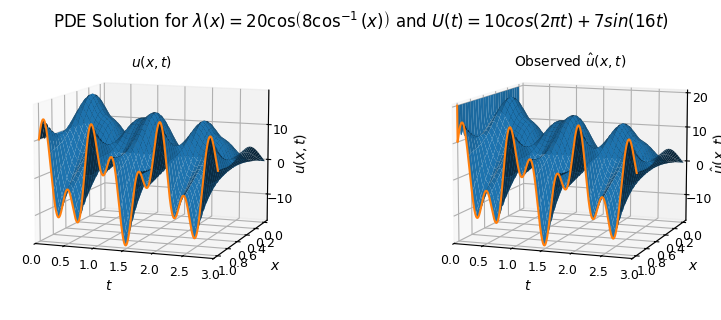

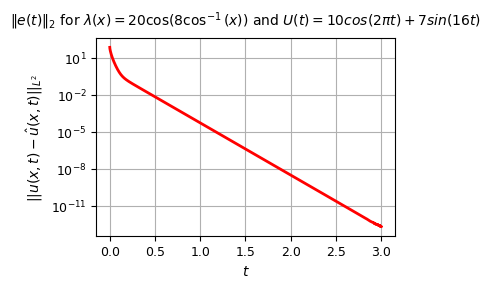

In [14]:
# Plot closed loop PDE u(x,t) and observed PDE u_hat(x,t) for λ(x) = 20cos(5ccos^-1(x)) and U(t) = 10cos(2πt)+7sin(16t)
plot_pde(pde3.x, pde3.t, [u3_ol, u3_ol_hat], fig_title=r'PDE Solution for $\lambda(x)=20\cos\!\left(8\cos^{-1}(x)\right)$ and $U(t)=10cos(2\pi t)+7sin(16t)$', title=[r'$u(x,t)$', r'Observed $\hat{u}(x,t)$'], z_title=[r'$u(x,t)$', r'$\hat{u}(x,t)$'], cols=2)

# Plot Observation error
e3 = u3_ol - u3_ol_hat
plot_observer_error(pde3.t, e3, title=r'$\|e(t)\|_2$ for $\lambda(x)=20\cos\!\left(8\cos^{-1}(x)\right)$ and $U(t)=10cos(2\pi t)+7sin(16t)$')

Paper Results:

The paper does not include results for the observed solution when the kernel is computed using the finite difference method. It only includes observed solution results when the kernel is computed using neural operators, which is the main contribution of the paper.

---

# 4. Training Kernel Operator

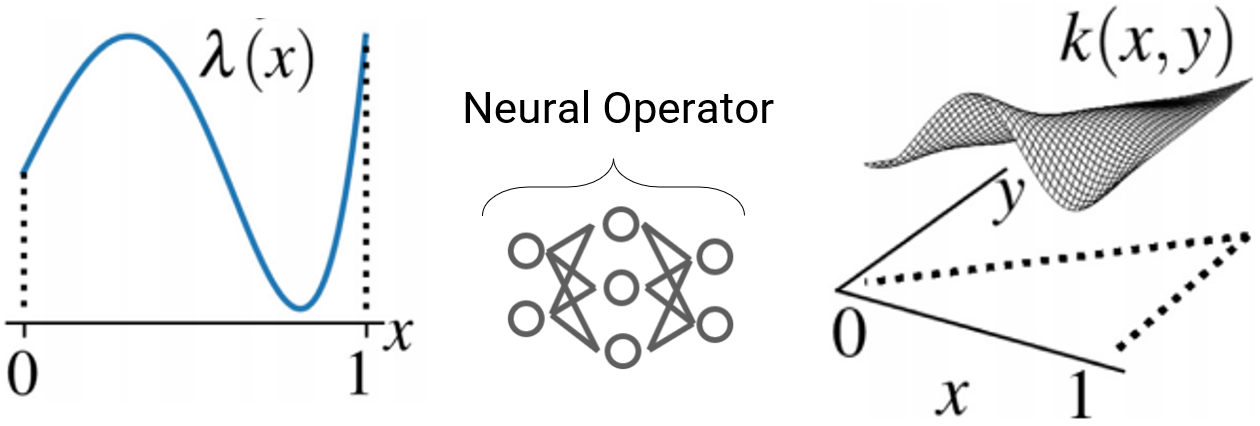

## 4-1. Create Dataset

$
\begin{align}
\lambda(x) = 50 \cos\!\left(\gamma \cos^{-1}(x)\right), 
\qquad \gamma \sim Uniform(4,9).
\end{align}
$

In [15]:
# Sample dataset λ(x) = 50cos(γccos^-1(x))
x, lambda_dataset, gammas = generate_lambda_dataset(n_samples=6, nx=51)

# Sample dataset k(x,y)
kernel_dataset = generate_kernel_dataset(lambda_dataset)

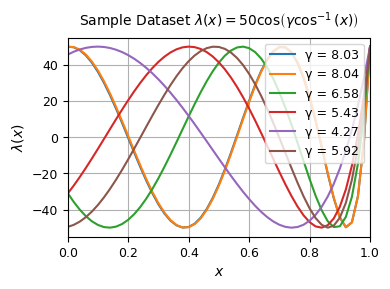

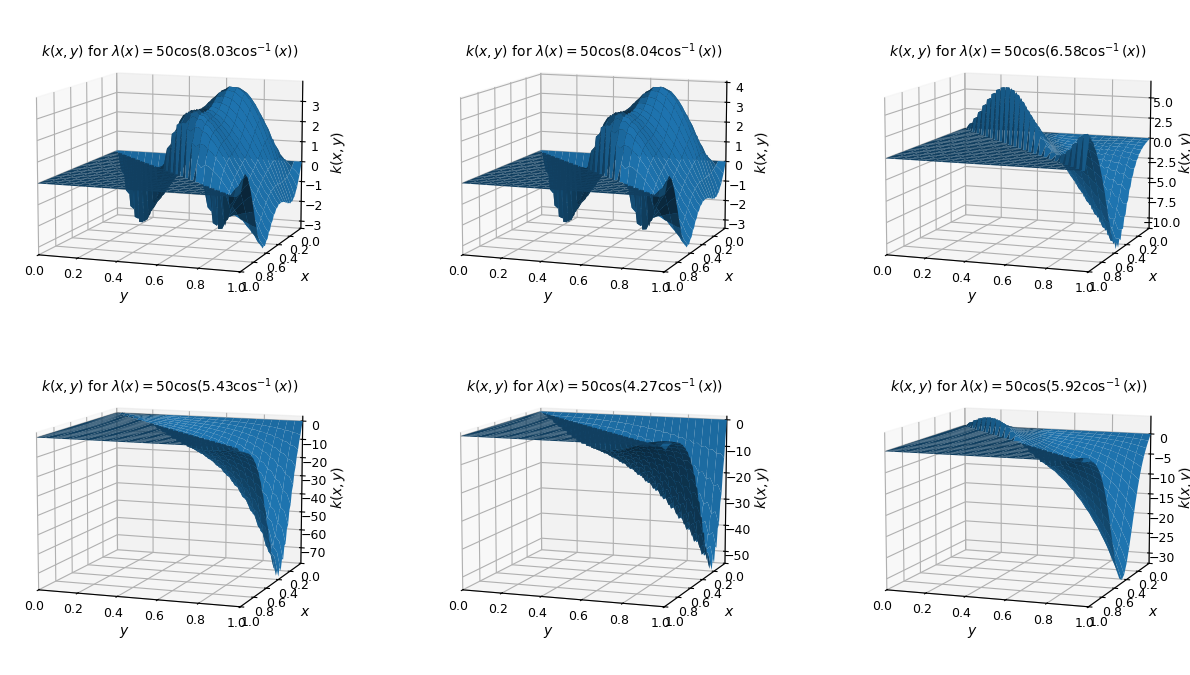

In [16]:
# Plot sample dataset λ(x) = 50cos(γccos^-1(x))
plot_lambda(x, lambda_dataset, gammas, title=r'Sample Dataset $\lambda(x)=50\cos\!\left(\gamma\cos^{-1}(x)\right)$')

# Plot sample dataset k(x,y)
plot_kernel(x, kernel_dataset, fig_title='', title=[rf"$k(x,y)$ for $\lambda(x)=50\cos\!\left({g:.2f}\cos^{{-1}}(x)\right)$" for g in gammas], z_title=[r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$', r'$k(x,y)$'], cols=3)

## 4-2. Training Operator

In [17]:
# Training operator for small sample and simple network
Operator = train_deeponet_model(x, lambda_dataset, kernel_dataset, n_samples=6, nx=51, hidden_size=16)

Compiling model...
'compile' took 2.018277 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [7.20e+01]    [3.74e+01]    [1.01e+00]    
500       [7.45e+00]    [1.48e+01]    [6.38e-01]    

Best model at step 500:
  train loss: 7.45e+00
  test loss: 1.48e+01
  test metric: [6.38e-01]

'train' took 2.887821 s

Compiling model...
'compile' took 0.001038 s

Training model...

Step      Train loss    Test loss     Test metric
500       [7.45e+00]    [1.48e+01]    []  
1500      [8.49e-02]    [1.28e+01]    []  
2500      [7.90e-02]    [1.39e+01]    []  
3085      [7.77e-02]    [1.59e+01]    []  

Best model at step 3085:
  train loss: 7.77e-02
  test loss: 1.59e+01
  test metric: []

'train' took 26.801462 s



## 4-3. Use Operator

In [18]:
# Use operator for compute kernel for λ(x) = 50cos(5ccos^-1(x))
k1_hat = compute_k_hat(lambda_func=lambda_func1, model=Operator, nx=51)

# Use operator for compute kernel for λ(x) = 50cos(8ccos^-1(x))
k2_hat = compute_k_hat(lambda_func=lambda_func2, model=Operator, nx=51)

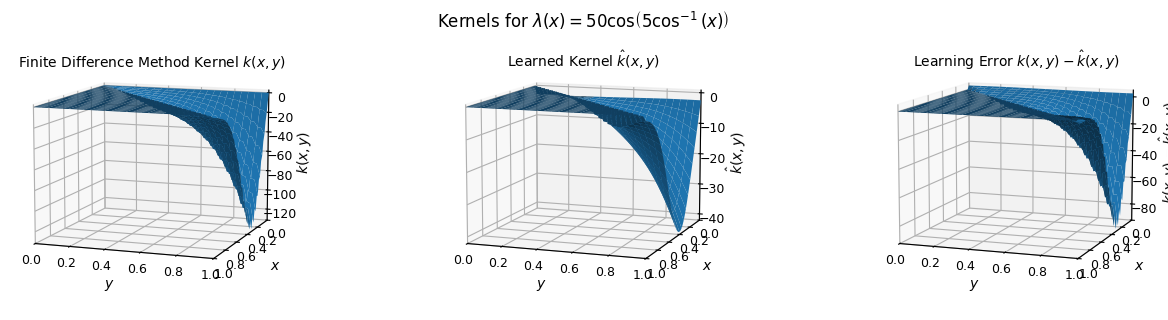

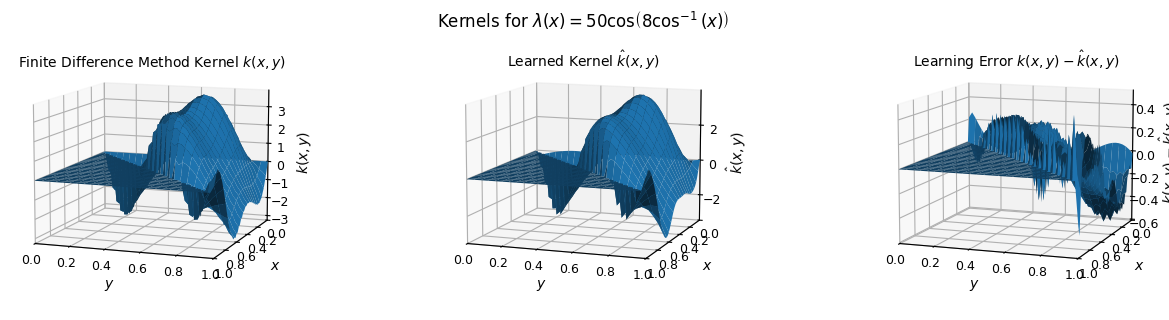

In [19]:
# Plot kernel and it's prediction for λ(x) = 50cos(5ccos^-1(x))
plot_kernel(x, kernel=[k1, k1_hat, k1-k1_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)

# Plot kernel and it's prediction for λ(x) = 50cos(8ccos^-1(x))
plot_kernel(x, kernel=[k2, k2_hat, k2-k2_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)

In [20]:
Operator, x, trunk_X = load_deeponet_model(nx=51, hidden_size=32, path="DeepOnet/Operator.pth-18947.pt")

Compiling model...
'compile' took 0.000785 s



In [21]:
# Use operator for compute kernel for λ(x) = 50cos(5ccos^-1(x))
k1_hat = compute_k_hat(lambda_func=lambda_func1, model=Operator, nx=51)

# Use operator for compute kernel for λ(x) = 50cos(5ccos^-1(x))
k2_hat = compute_k_hat(lambda_func=lambda_func2, model=Operator, nx=51)

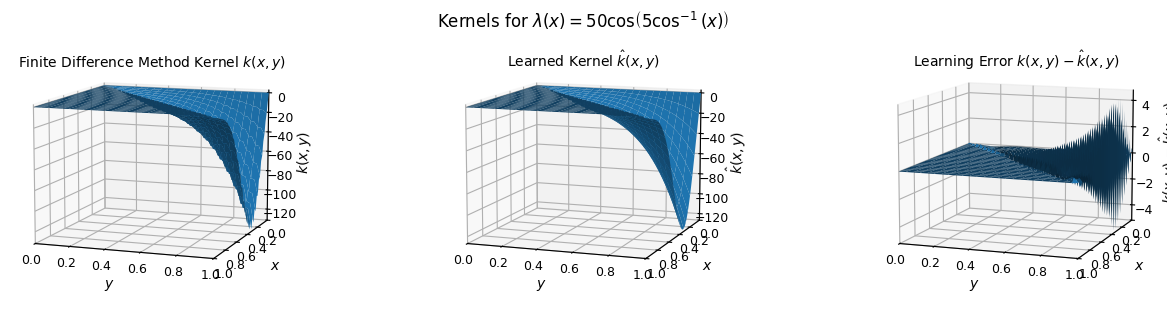

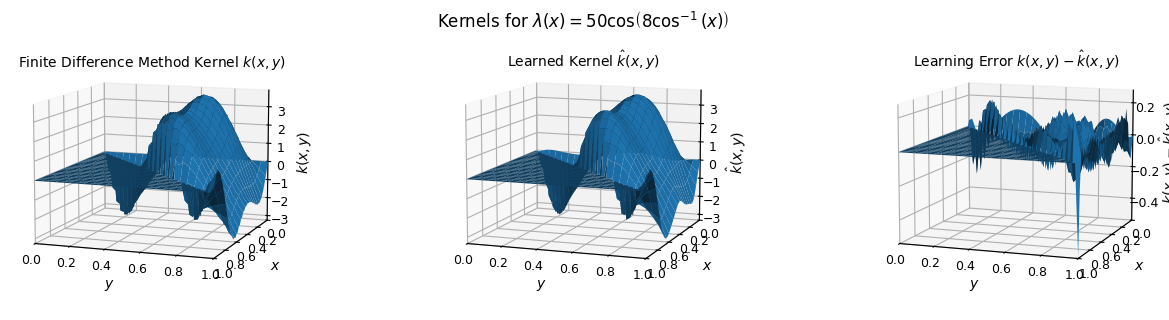

In [22]:
# Plot kernel and it's prediction for λ(x) = 50cos(5ccos^-1(x))
plot_kernel(x, kernel=[k1, k1_hat, k1-k1_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(5\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)

# Plot kernel and it's prediction for λ(x) = 50cos(8ccos^-1(x))
plot_kernel(x, kernel=[k2, k2_hat, k2-k2_hat], fig_title=r'Kernels for $\lambda(x)=50\cos\!\left(8\cos^{-1}(x)\right)$', title=[r'Finite Difference Method Kernel $k(x,y)$', r'Learned Kernel $\hat{k}(x,y)$', r'Learning Error $k(x,y)-\hat{k}(x,y)$'], z_title=[r'$k(x,y)$', r'$\hat{k}(x,y)$', r'$k(x,y)-\hat{k}(x,y)$'], cols=3)